In [23]:
from scanspec.specs import Spec, Polygon, Linspace
from scanspec.plot import plot_spec
from scanspec.core import stack2dimension
import numpy as np
from pprint import pprint

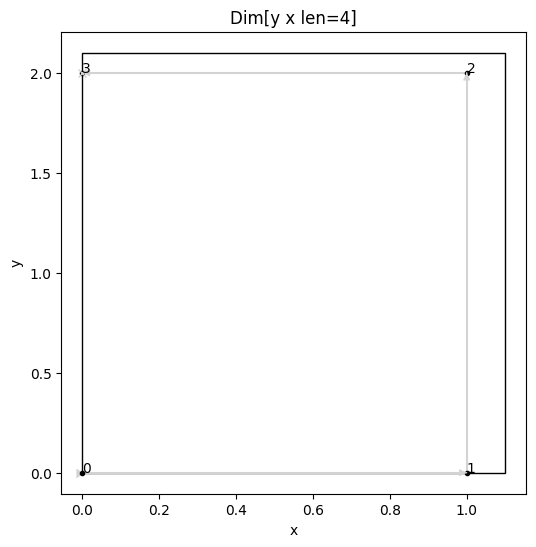

In [2]:
spec2 = Polygon("x", "y",
               vertices=[(0,0), (1.1, 0), (1.1, 2.1), (0, 2.1)],
               x_step=1, y_step=2, snake=True)

plot_spec(spec2)

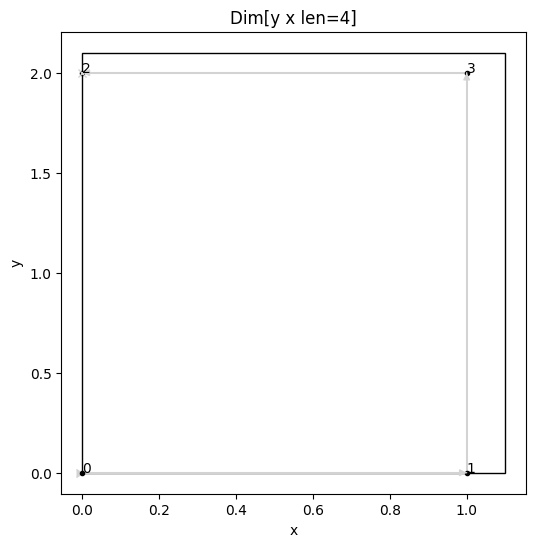

In [3]:
plot_spec(spec2, labels=[0, 1, 3, 2])

{'y': array([0., 0., 2., 2.]), 'x': array([0., 1., 1., 0.])}
[0 1 3 2]


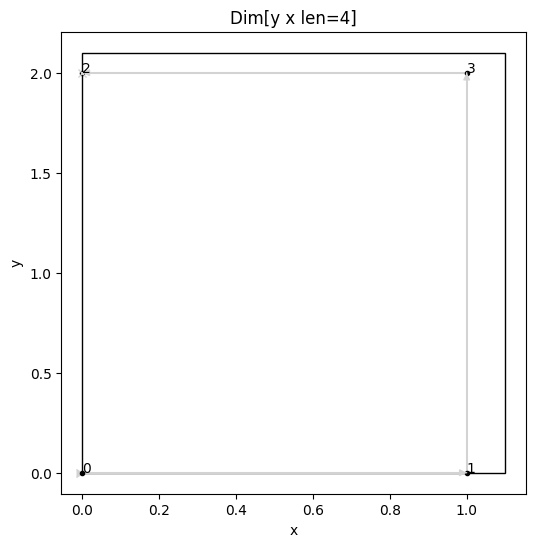

In [66]:
dim = stack2dimension(spec2.calculate()).midpoints
print(dim)
order = np.lexsort((dim['x'], dim['y']))
print(order)
plot_spec(spec2, labels=np.argsort(order))

In [15]:
spec3 = spec2 * ~Linspace("z", -3, 3, 2)

In [16]:
dim3 = stack2dimension(spec3.calculate()).midpoints
print(dim3)

{'y': array([0., 0., 0., 0., 2., 2., 2., 2.]), 'x': array([0., 0., 1., 1., 1., 1., 0., 0.]), 'z': array([-3.,  3.,  3., -3., -3.,  3.,  3., -3.])}


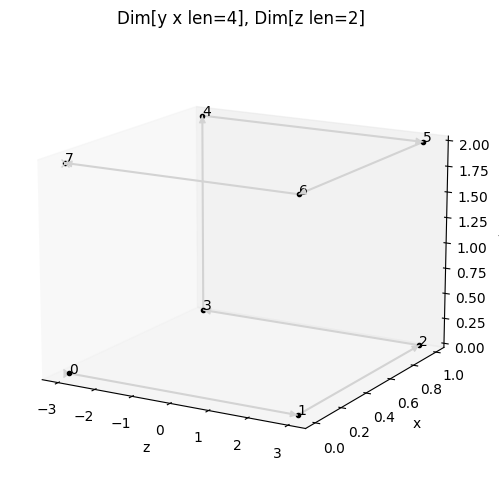

In [ ]:
plot_spec(spec3)

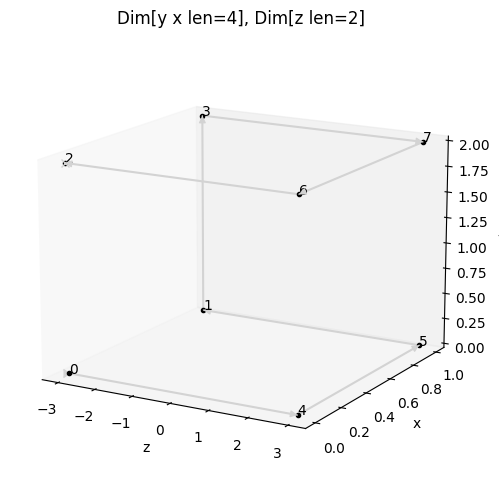

In [33]:
# plot_spec(spec3, labels=[4, 0, 1, 5, 7, 3, 2, 6])
# plot_spec(spec3, labels=[0, 1, 2, 3, 4, 5, 6, 7])
plot_spec(spec3, labels=[0, 4, 5, 1, 3, 7, 6, 2])

{'x': array([0., 0., 1., 1., 1., 1., 0., 0.]),
 'y': array([0., 0., 0., 0., 2., 2., 2., 2.]),
 'z': array([-3.,  3.,  3., -3., -3.,  3.,  3., -3.])}
[0 3 7 4 1 2 6 5]


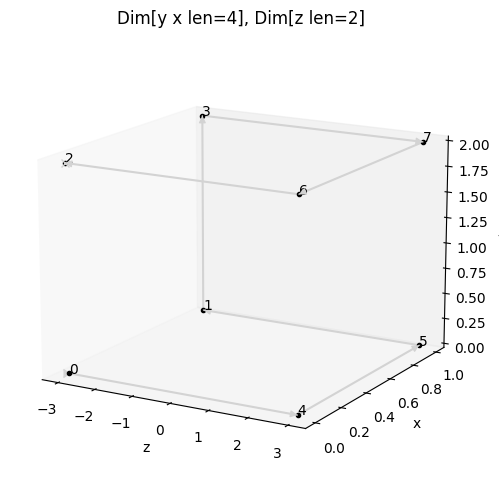

In [65]:
dim = stack2dimension(spec3.calculate()).midpoints
pprint(dim)
order = np.lexsort(( dim['x'],dim['y'],dim['z'],))
print(order)
plot_spec(spec3, labels=np.argsort(order))

In [68]:
                  # 0    1    2    3    4    5    6    7
                  # 0    3    7    4    1    2    6    5  <--- lexsorted
dim = {           # 0    4    5    1    3    7    6    2  <--- argsorted
    'x': np.array([ 0.,  0.,  1.,  1.,  1.,  1.,  0.,  0.]),
    'y': np.array([ 0.,  0.,  0.,  0.,  2.,  2.,  2.,  2.]),
    'z': np.array([-3.,  3.,  3., -3., -3.,  3.,  3., -3.])
}
labels = np.argsort(np.lexsort((dim['x'], dim['y'], dim['z'])))
print(labels)

[0 4 5 1 3 7 6 2]


In [75]:
dim = stack2dimension(spec3.calculate()).midpoints
x, y, z = dim['x'], dim['y'], dim['z']
order = np.lexsort((x, y, z))
slizable = order.reshape((2, 2, 2))
print(slizable)

[[[0 3]
  [7 4]]

 [[1 2]
  [6 5]]]


In [77]:
sx = slizable[:1, :, :]
pprint((x[sx], y[sx], z[sx]))

(array([[[0., 1.],
        [0., 1.]]]),
 array([[[0., 0.],
        [2., 2.]]]),
 array([[[-3., -3.],
        [-3., -3.]]]))


In [79]:
pprint(spec3)

Product(outer=Polygon(x_axis='x',
                      y_axis='y',
                      vertices=[(0.0, 0.0), (1.1, 0.0), (1.1, 2.1), (0.0, 2.1)],
                      x_step=1.0,
                      y_step=2.0,
                      snake=True,
                      vertical=False),
        inner=Snake(spec=Linspace(axis='z', start=-3.0, stop=3.0, num=2)),
        gap=True)
